# Cross-model results (CLAY / AlphaEarth)

Loads every `*.parquet` under this folder (plus `metrics_overall_*.json` and `metrics_by_state_*.csv` where present) and builds comparison plots.

**Layout:** top-level experiment folders (`clay2010/`, `clay2020/`, `alphaearth2020/`, …) each contain `analysis_ageb/`, `analysis_muni_rollup/`, `analysis_muni_direct/` with the same artifact names CLAY uses. **AlphaEarth:** regenerate with `python scripts/evaluation/export_results_analysis_artifacts.py` from `alphaearth_src/`.

**Kernel:** `pandas`, `pyarrow`, `matplotlib`, `seaborn` (e.g. conda Python 3.12).

In [22]:
from __future__ import annotations

import json
import os
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display

os.environ.setdefault("TF_CPP_MIN_LOG_LEVEL", "2")

sns.set_theme(style="whitegrid", font_scale=1.05)
plt.rcParams["figure.dpi"] = 110


def resolve_results_dir() -> Path:
    """Find `results_analysis` when cwd is thesis root, this folder, or a subfolder."""
    start = Path.cwd().resolve()
    if start.name == "results_analysis":
        return start
    for base in [start, *start.parents]:
        cand = base / "results_analysis"
        if cand.is_dir():
            return cand
    raise FileNotFoundError(
        "Could not find `results_analysis`. Open/run from the thesis tree or cd into results_analysis."
    )


RESULTS_DIR = resolve_results_dir()
print("RESULTS_DIR =", RESULTS_DIR)

# Consistent ordering in plots (unknown experiments sort last)
EXPERIMENT_ORDER = ["clay2010", "clay2020", "alphaearth2020"]
ANALYSIS_ORDER = ["analysis_ageb", "analysis_muni_rollup", "analysis_muni_direct"]


def _rank(values: pd.Series, order: list[str]) -> pd.Series:
    m = {name: i for i, name in enumerate(order)}
    return values.map(m).fillna(len(order) + 1)

RESULTS_DIR = /Users/henrychen/Desktop/CS-Econ Thesis/results_analysis


## Discover artifacts

In [23]:
parquet_paths = sorted(RESULTS_DIR.rglob("*.parquet"))
json_paths = sorted(RESULTS_DIR.rglob("metrics_overall*.json"))
state_csv_paths = sorted(RESULTS_DIR.rglob("metrics_by_state*.csv"))

print(f"Parquet files: {len(parquet_paths)}")
for p in parquet_paths:
    print(" ", p.relative_to(RESULTS_DIR))

# Count artifacts by top-level experiment folder
rows = []
for kind, paths in [
    ("parquet", parquet_paths),
    ("metrics_json", json_paths),
    ("metrics_by_state_csv", state_csv_paths),
]:
    for p in paths:
        rel = p.relative_to(RESULTS_DIR)
        exp = rel.parts[0] if len(rel.parts) > 1 else "root"
        rows.append({"experiment": exp, "kind": kind})
if rows:
    ct = (
        pd.DataFrame(rows)
        .groupby(["experiment", "kind"], observed=False)
        .size()
        .unstack(fill_value=0)
        .astype(int)
    )
    display(ct)

Parquet files: 12
  alphaearth2020/analysis_ageb/predictions_oof_emb.parquet
  alphaearth2020/analysis_muni_direct/predictions_oof_emb.parquet
  alphaearth2020/analysis_muni_rollup/predictions_oof_emb.parquet
  clay2010/analysis_ageb/predictions_oof_emb.parquet
  clay2010/analysis_muni_direct/predictions_oof_emb.parquet
  clay2010/analysis_muni_rollup/predictions_oof_emb.parquet
  clay2020/analysis_ageb/predictions_oof_emb.parquet
  clay2020/analysis_muni_direct/predictions_oof_emb.parquet
  clay2020/analysis_muni_rollup/predictions_oof_emb.parquet
  clay2020/cross_temporal/predictions_baseline_2010_2020_cv.parquet
  clay2020/cross_temporal/predictions_baseline_delta_2020_cv.parquet
  clay2020/cross_temporal/predictions_transfer_2010_to_2020.parquet


kind,metrics_by_state_csv,metrics_json,parquet
experiment,,,
alphaearth2020,3,3,3
clay2010,3,3,3
clay2020,6,6,6


## Overall metrics (JSON): Ridge vs XGBoost across runs

Each `metrics_overall_*.json` is flattened into one row for bar charts.

In [24]:
def load_metrics_overall_rows(paths: list[Path]) -> pd.DataFrame:
    rows: list[dict] = []
    for path in paths:
        with open(path) as f:
            doc = json.load(f)
        rel = path.relative_to(RESULTS_DIR)
        parts = rel.parts
        experiment = parts[0] if len(parts) > 1 else "root"
        subpath = "/".join(parts[1:-1]) if len(parts) > 2 else ""
        metrics = doc.get("metrics") or {}
        for model_name, m in metrics.items():
            rows.append(
                {
                    "json_path": str(rel),
                    "experiment": experiment,
                    "analysis": subpath or "(top)",
                    "target": doc.get("target"),
                    "experiment_type": doc.get("experiment"),
                    "unit_name": doc.get("unit_name"),
                    "model": model_name,
                    "r2": m.get("r2"),
                    "mae": m.get("mae"),
                    "rmse": m.get("rmse"),
                    "n": m.get("n"),
                }
            )
    return pd.DataFrame(rows)


metrics_df = load_metrics_overall_rows(json_paths)
if metrics_df.empty:
    print("No metrics_overall*.json found yet.")
else:
    metrics_df = metrics_df.copy()
    metrics_df["label"] = metrics_df["experiment"] + " / " + metrics_df["analysis"]
    metrics_df["_exp_rank"] = _rank(metrics_df["experiment"], EXPERIMENT_ORDER)
    metrics_df["_ana_rank"] = _rank(metrics_df["analysis"], ANALYSIS_ORDER)
    print(f"metrics rows: {len(metrics_df)}")
    display(
        metrics_df.sort_values(["_exp_rank", "_ana_rank", "model"]).drop(
            columns=["_exp_rank", "_ana_rank"], errors="ignore"
        )
    )

metrics rows: 24


,json_path,experiment,analysis,target,experiment_type,unit_name,model,r2,mae,rmse,n,label
6,clay2010/analysis_ageb/metrics_overall_emb.json,clay2010,analysis_ageb,log_popden,None,AGEBs,ridge,0.566523,0.632819,0.919557,53522,clay2010 / analysis_ageb
7,clay2010/analysis_ageb/metrics_overall_emb.json,clay2010,analysis_ageb,log_popden,None,AGEBs,xgboost,0.622888,0.579661,0.857691,53522,clay2010 / analysis_ageb
10,clay2010/analysis_muni_rollup/metrics_overall_...,clay2010,analysis_muni_rollup,log_popden,None,municipios,ridge,0.708254,0.324563,0.427761,2456,clay2010 / analysis_muni_rollup
11,clay2010/analysis_muni_rollup/metrics_overall_...,clay2010,analysis_muni_rollup,log_popden,None,municipios,xgboost,0.691131,0.334528,0.440135,2456,clay2010 / analysis_muni_rollup
8,clay2010/analysis_muni_direct/metrics_overall_...,clay2010,analysis_muni_direct,log_popden,None,municipios,ridge,0.708712,0.324777,0.427346,2456,clay2010 / analysis_muni_direct
9,clay2010/analysis_muni_direct/metrics_overall_...,clay2010,analysis_muni_direct,log_popden,None,municipios,xgboost,0.692253,0.334317,0.439253,2456,clay2010 / analysis_muni_direct
12,clay2020/analysis_ageb/metrics_overall_emb.json,clay2020,analysis_ageb,log_popden,None,AGEBs,ridge,0.489940,0.657042,0.943932,106564,clay2020 / analysis_ageb
13,clay2020/analysis_ageb/metrics_overall_emb.json,clay2020,analysis_ageb,log_popden,None,AGEBs,xgboost,0.587918,0.580148,0.848442,106564,clay2020 / analysis_ageb
16,clay2020/analysis_muni_rollup/metrics_overall_...,clay2020,analysis_muni_rollup,log_popden,None,municipios,ridge,0.742164,0.289389,0.383820,2469,clay2020 / analysis_muni_rollup
17,clay2020/analysis_muni_rollup/metrics_overall_...,clay2020,analysis_muni_rollup,log_popden,None,municipios,xgboost,0.763411,0.279365,0.367666,2469,clay2020 / analysis_muni_rollup


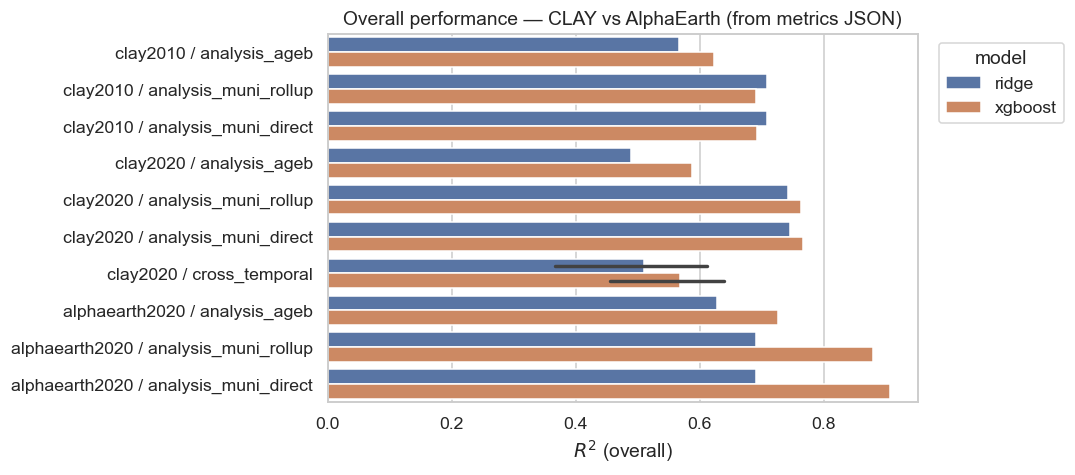

In [25]:
if not metrics_df.empty:
    plot_df = metrics_df[metrics_df["model"].isin(["ridge", "xgboost"])].copy()
    plot_df = plot_df.sort_values(["_exp_rank", "_ana_rank", "r2"])
    plot_df["label"] = pd.Categorical(
        plot_df["label"], categories=plot_df["label"].unique(), ordered=True
    )
    n_lab = plot_df["label"].nunique()
    fig_h = min(28, max(4.5, 0.36 * n_lab))
    fig, ax = plt.subplots(figsize=(10, fig_h))
    sns.barplot(
        data=plot_df,
        y="label",
        x="r2",
        hue="model",
        hue_order=["ridge", "xgboost"],
        ax=ax,
    )
    ax.set_xlabel(r"$R^2$ (overall)")
    ax.set_ylabel("")
    ax.set_title("Overall performance — CLAY vs AlphaEarth (from metrics JSON)")
    ax.legend(title="model", bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.tight_layout()
    plt.show()

## Per-state $R^2$ (XGBoost) — `analysis_ageb`

Polygon / AGEB-scale rows: compares each experiment’s `analysis_ageb/metrics_by_state_*.csv` (XGBoost only).

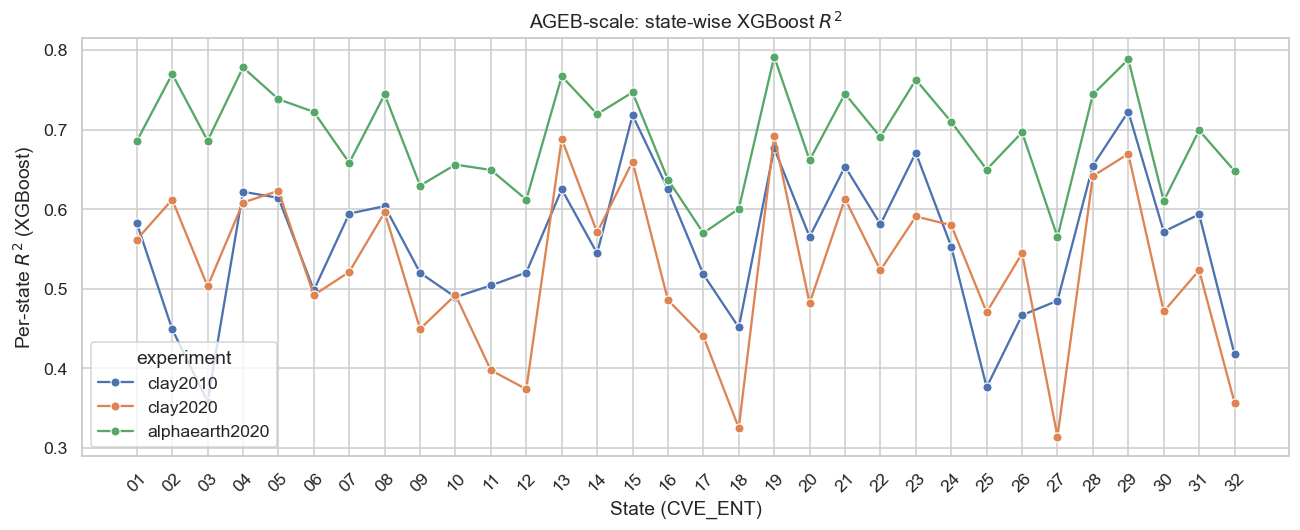

In [26]:
def load_state_metrics_ageb_xgb() -> pd.DataFrame:
    frames: list[pd.DataFrame] = []
    for p in state_csv_paths:
        rel = p.relative_to(RESULTS_DIR)
        if "analysis_ageb" not in rel.parts:
            continue
        df = pd.read_csv(p)
        df = df[df["model"] == "xgboost"].copy()
        df["experiment"] = rel.parts[0]
        frames.append(df)
    if not frames:
        return pd.DataFrame()
    return pd.concat(frames, ignore_index=True)


state_xgb = load_state_metrics_ageb_xgb()
if state_xgb.empty:
    print("No per-state CSV under analysis_ageb.")
else:
    state_xgb = state_xgb.copy()
    state_xgb["state"] = state_xgb["state"].astype(str).str.zfill(2)
    state_xgb["_hue_rank"] = _rank(state_xgb["experiment"], EXPERIMENT_ORDER)
    order = sorted(state_xgb["state"].unique())
    state_xgb["state_cat"] = pd.Categorical(state_xgb["state"], categories=order, ordered=True)
    fig, ax = plt.subplots(figsize=(12, 5))
    hue_ord = (
        state_xgb.sort_values("_hue_rank")["experiment"].drop_duplicates().tolist()
    )
    sns.lineplot(
        data=state_xgb,
        x="state_cat",
        y="r2",
        hue="experiment",
        hue_order=hue_ord,
        marker="o",
        ax=ax,
    )
    ax.set_xlabel("State (CVE_ENT)")
    ax.set_ylabel(r"Per-state $R^2$ (XGBoost)")
    ax.set_title("AGEB-scale: state-wise XGBoost $R^2$")
    ax.tick_params(axis="x", rotation=45)
    plt.tight_layout()
    plt.show()

## Per-state $R^2$ (XGBoost) — `analysis_muni_rollup`

Municipio-level rolled-up targets (CLAY embedding pipeline vs AlphaEarth polygon rollup). Same CSV pattern as AGEB, filtered to `analysis_muni_rollup/`.

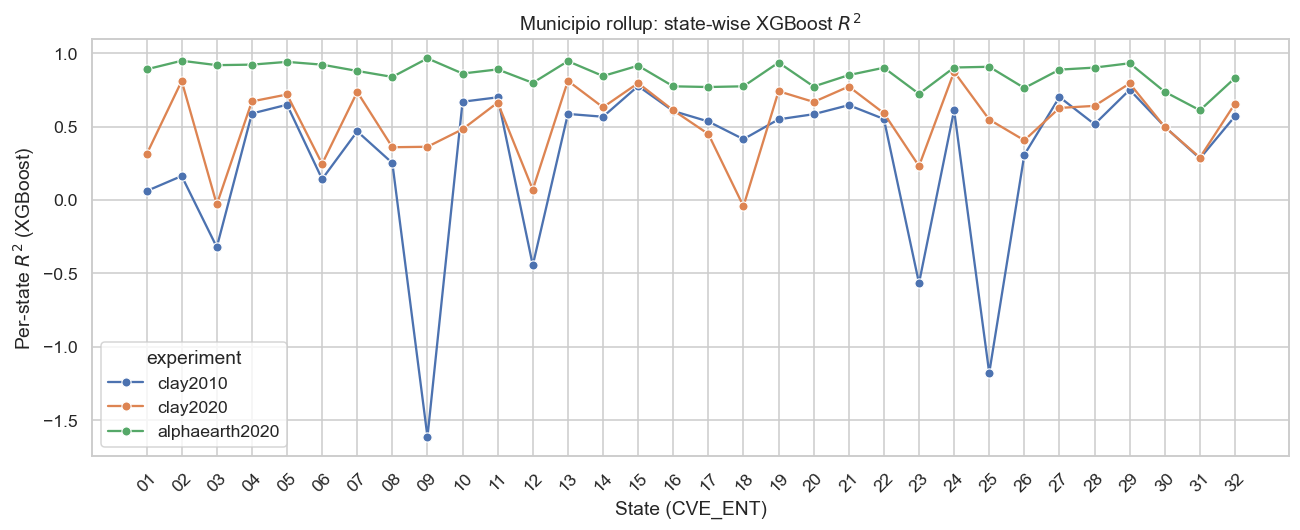

In [27]:
def load_state_metrics_subdir_xgb(subdir: str) -> pd.DataFrame:
    frames: list[pd.DataFrame] = []
    for p in state_csv_paths:
        rel = p.relative_to(RESULTS_DIR)
        if subdir not in rel.parts:
            continue
        df = pd.read_csv(p)
        df = df[df["model"] == "xgboost"].copy()
        df["experiment"] = rel.parts[0]
        frames.append(df)
    if not frames:
        return pd.DataFrame()
    return pd.concat(frames, ignore_index=True)


state_muni_roll = load_state_metrics_subdir_xgb("analysis_muni_rollup")
if state_muni_roll.empty:
    print("No per-state CSV under analysis_muni_rollup.")
else:
    g = state_muni_roll.copy()
    g["state"] = g["state"].astype(str).str.zfill(2)
    g["_hue_rank"] = _rank(g["experiment"], EXPERIMENT_ORDER)
    order = sorted(g["state"].unique())
    g["state_cat"] = pd.Categorical(g["state"], categories=order, ordered=True)
    fig, ax = plt.subplots(figsize=(12, 5))
    hue_ord = g.sort_values("_hue_rank")["experiment"].drop_duplicates().tolist()
    sns.lineplot(
        data=g,
        x="state_cat",
        y="r2",
        hue="experiment",
        hue_order=hue_ord,
        marker="o",
        ax=ax,
    )
    ax.set_xlabel("State (CVE_ENT)")
    ax.set_ylabel(r"Per-state $R^2$ (XGBoost)")
    ax.set_title("Municipio rollup: state-wise XGBoost $R^2$")
    ax.tick_params(axis="x", rotation=45)
    plt.tight_layout()
    plt.show()

## Parquet predictions: pred vs actual + residuals

Expects columns `y` plus `pred_ridge` and either `pred_xgb` or `pred_xgboost`. Large tables are subsampled for scatter clarity.

Figures run in **experiment → analysis** order (`clay2010` / `clay2020` / `alphaearth2020`, then `analysis_ageb` / `analysis_muni_*`). Use `PLOT_LIMIT` to cap how many files get plots.

In [28]:
def normalize_pred_frame(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    if "pred_xgboost" in out.columns and "pred_xgb" not in out.columns:
        out["pred_xgb"] = out["pred_xgboost"]
    return out


def plot_pred_diagnostics(df: pd.DataFrame, title: str, n_sample: int = 8000, seed: int = 0) -> None:
    df = normalize_pred_frame(df)
    need = {"y", "pred_ridge", "pred_xgb"}
    if not need.issubset(df.columns):
        print(f"[skip] {title}: missing columns {need - set(df.columns)}")
        return
    rng = np.random.default_rng(seed)
    if len(df) > n_sample:
        idx = rng.choice(len(df), size=n_sample, replace=False)
        sub = df.iloc[idx]
    else:
        sub = df

    fig, axes = plt.subplots(1, 2, figsize=(11, 4))
    for ax, col, name in zip(
        axes,
        ["pred_ridge", "pred_xgb"],
        ["Ridge", "XGBoost"],
    ):
        ax.scatter(sub["y"], sub[col], s=4, alpha=0.25, color="0.25")
        lims = [min(sub["y"].min(), sub[col].min()), max(sub["y"].max(), sub[col].max())]
        ax.plot(lims, lims, ls="--", color="C0", lw=1)
        ax.set_xlabel("y (log target)")
        ax.set_ylabel("prediction")
        ax.set_title(f"{name}: pred vs actual")
    fig.suptitle(title)
    plt.tight_layout()
    plt.show()

    resid = sub["pred_xgb"] - sub["y"]
    fig, ax = plt.subplots(figsize=(6, 3.5))
    ax.hist(resid, bins=50, color="0.35", edgecolor="white")
    ax.set_title(f"{title} — XGBoost residual (n={len(sub):,})")
    ax.set_xlabel("pred − y")
    plt.tight_layout()
    plt.show()

## Calibration: $\ln(\text{actual})$ vs.\ $\ln(\text{predicted})$ and residuals

For each entry in `PUBLICATION_SOURCES`, the notebook draws **two** **1×2** figures (same fonts/theme as the rest of the notebook — no extra `rcParams` here):

1. **Calibration** — `hexbin` of $\ln(d)$ vs.\ $\ln(\hat d)$ (Ridge | XGBoost), $\log_{10}$ cell counts on the colorbar, identity ($45^\circ$) line.
2. **Residuals** — **Histogram bars** with `density=True` (total bar area = 1): OOF errors $y-\hat y$ on the log-density scale. Visible edges and `rwidth<1` so bars read clearly. Blue curve = Gaussian with the sample mean/SD (informal reference only).

`subplots_adjust` reserves space so suptitles and panel titles do not overlap. Requires `normalize_pred_frame` from the cell above. Adjust `MAX_POINTS` if needed.

Figures are written to ``deliverables/report/figs/`` as ``oof_calibration_<folder>.*`` and ``oof_residuals_<folder>.*``.

Each panel shows **OOF $R^2$** on the $\ln$-density target (same scale as Table~8 $R^2_{\ln}$). The calibration identity line is labeled **$y=x$** in the legend.


Saved: /Users/henrychen/Desktop/CS-Econ Thesis/deliverables/report/figs/oof_calibration_alphaearth2020.pdf | /Users/henrychen/Desktop/CS-Econ Thesis/deliverables/report/figs/oof_calibration_alphaearth2020.png


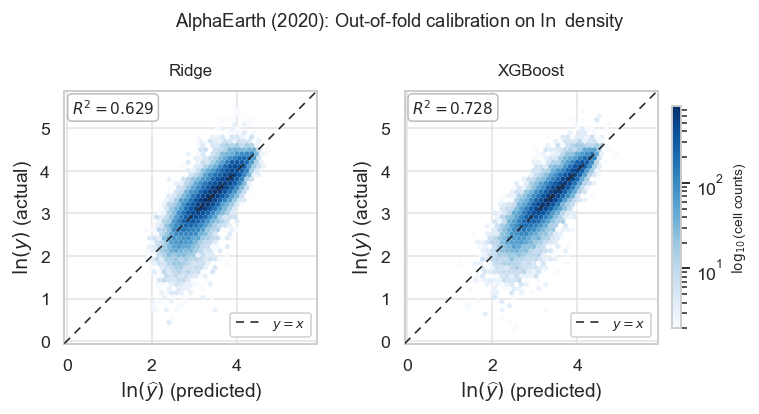

Saved: /Users/henrychen/Desktop/CS-Econ Thesis/deliverables/report/figs/oof_residuals_alphaearth2020.pdf | /Users/henrychen/Desktop/CS-Econ Thesis/deliverables/report/figs/oof_residuals_alphaearth2020.png


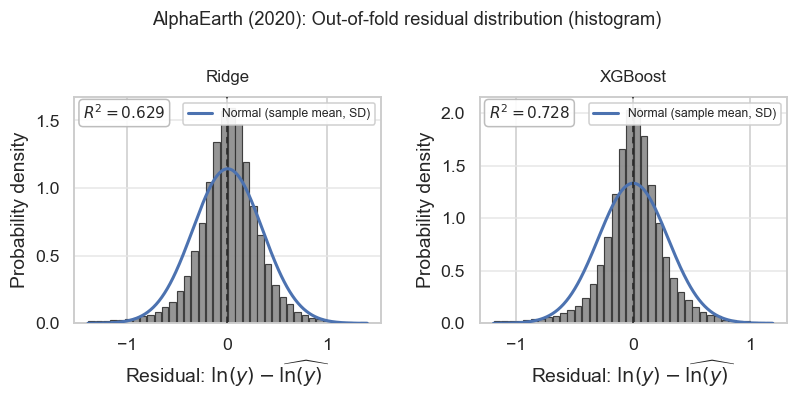

Saved: /Users/henrychen/Desktop/CS-Econ Thesis/deliverables/report/figs/oof_calibration_clay2020.pdf | /Users/henrychen/Desktop/CS-Econ Thesis/deliverables/report/figs/oof_calibration_clay2020.png


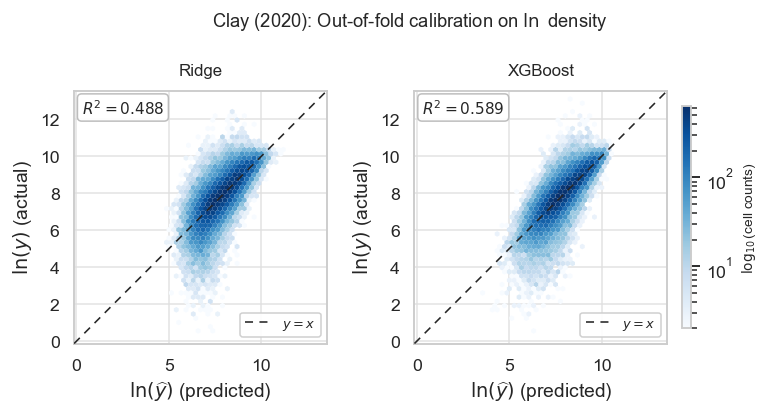

Saved: /Users/henrychen/Desktop/CS-Econ Thesis/deliverables/report/figs/oof_residuals_clay2020.pdf | /Users/henrychen/Desktop/CS-Econ Thesis/deliverables/report/figs/oof_residuals_clay2020.png


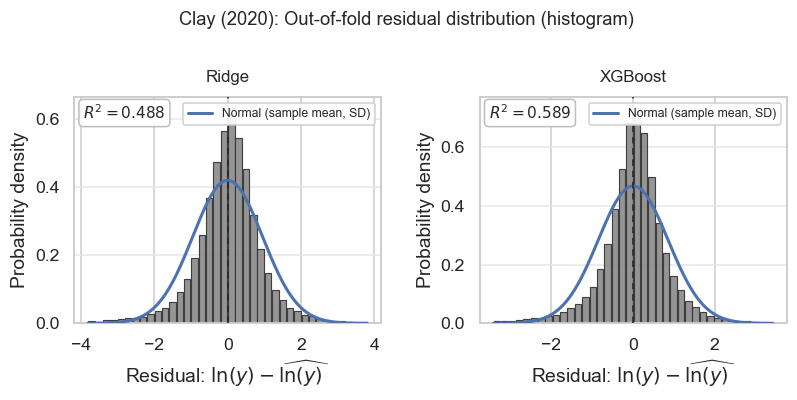

Saved: /Users/henrychen/Desktop/CS-Econ Thesis/deliverables/report/figs/oof_calibration_clay2010.pdf | /Users/henrychen/Desktop/CS-Econ Thesis/deliverables/report/figs/oof_calibration_clay2010.png


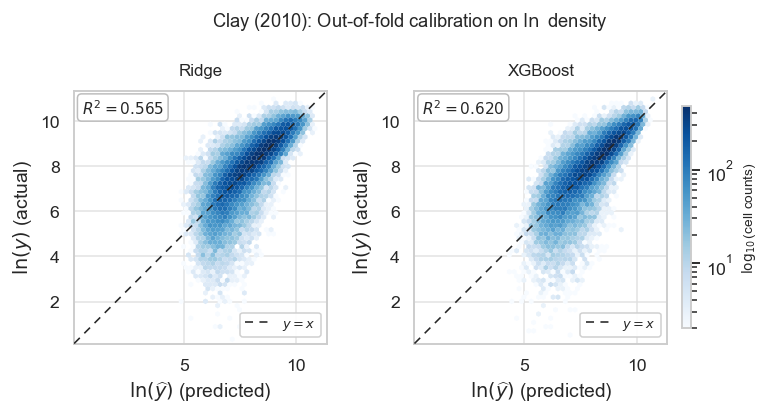

Saved: /Users/henrychen/Desktop/CS-Econ Thesis/deliverables/report/figs/oof_residuals_clay2010.pdf | /Users/henrychen/Desktop/CS-Econ Thesis/deliverables/report/figs/oof_residuals_clay2010.png


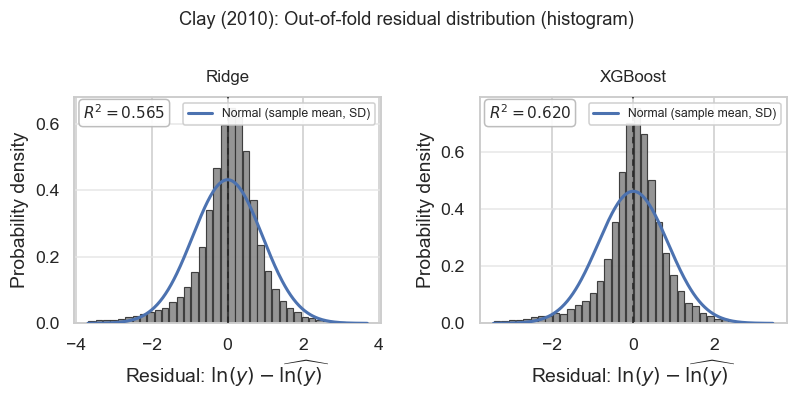

Figure directory: /Users/henrychen/Desktop/CS-Econ Thesis/deliverables/report/figs
Stem names: ``oof_calibration_<folder>`` and ``oof_residuals_<folder>`` (.pdf / .png). $R^2$ on panels is OOF $R^2$ on $\ln$-density (``sklearn``). Edit PUBLICATION_SOURCES / MAX_POINTS as needed.


In [29]:
# Three embedding × year pairs: two 1×2 figures each — hexbin calibration + bar-histogram residuals.
# Uses the notebook theme from earlier cells (no font / rc overrides in this cell).
# Saves each figure to ``deliverables/report/figs/`` (PDF + PNG) for the thesis.

from sklearn.metrics import r2_score

PUBLICATION_SOURCES: list[tuple[str, str]] = [
    ("AlphaEarth (2020)", "alphaearth2020"),
    ("Clay (2020)", "clay2020"),
    ("Clay (2010)", "clay2010"),
]
MAX_POINTS = 40_000
RNG = np.random.default_rng(42)

# Thesis report figures (sibling of ``results_analysis/``)
CAL_RES_FIG_DIR = RESULTS_DIR.parent / "deliverables" / "report" / "figs"
CAL_RES_FIG_DIR.mkdir(parents=True, exist_ok=True)


def _save_report_fig(fig, stem: str) -> None:
    """Write vector + raster copies next to ``report.tex``."""
    base = CAL_RES_FIG_DIR / stem
    fig.savefig(base.with_suffix(".pdf"), bbox_inches="tight")
    fig.savefig(base.with_suffix(".png"), dpi=220, bbox_inches="tight")
    print("Saved:", base.with_suffix(".pdf"), "|", base.with_suffix(".png"))


def _norm_pdf(x: np.ndarray, mu: float, sig: float) -> np.ndarray:
    z = (x - mu) / sig
    return np.exp(-0.5 * z * z) / (sig * np.sqrt(2.0 * np.pi))


def _load_ageb_oof(folder: str) -> pd.DataFrame | None:
    p = RESULTS_DIR / folder / "analysis_ageb" / "predictions_oof_emb.parquet"
    if not p.is_file():
        return None
    return normalize_pred_frame(pd.read_parquet(p))


def _subsample(df: pd.DataFrame) -> pd.DataFrame:
    if len(df) <= MAX_POINTS:
        return df
    idx = RNG.choice(len(df), size=MAX_POINTS, replace=False)
    return df.iloc[idx]


def _panel_limits(y: np.ndarray, pred_r: np.ndarray, pred_x: np.ndarray) -> tuple[float, float]:
    lo = float(min(y.min(), pred_r.min(), pred_x.min()))
    hi = float(max(y.max(), pred_r.max(), pred_x.max()))
    pad = 0.02 * (hi - lo)
    return lo - pad, hi + pad


def _residual_bin_edges(res: np.ndarray) -> np.ndarray:
    """Bin edges spanning most residual mass (symmetric around mean, capped at 8 sigma width)."""
    mu, sig = float(res.mean()), float(res.std(ddof=1))
    if sig < 1e-10:
        sig = 1.0
    span = min(float(res.max() - res.min()), 8.0 * sig)
    half = 0.5 * span
    lo, hi = mu - half, mu + half
    n_bins = 38
    return np.linspace(lo, hi, n_bins + 1)


def _r2_ln(yv: np.ndarray, pv: np.ndarray) -> float:
    """R² on the OOF log-density target (same scale as Table 8 ``R^2_ln``)."""
    return float(r2_score(yv, pv))


def _annotate_r2(ax, r2v: float) -> None:
    ax.text(
        0.03,
        0.97,
        rf"$R^2 = {r2v:.3f}$",
        transform=ax.transAxes,
        fontsize=10,
        va="top",
        ha="left",
        bbox=dict(boxstyle="round,pad=0.28", facecolor="white", edgecolor="0.72", alpha=0.92),
        zorder=10,
    )


for lab, fold in PUBLICATION_SOURCES:
    d0 = _load_ageb_oof(fold)
    if d0 is None:
        print(f"[skip] missing: {fold}/analysis_ageb/predictions_oof_emb.parquet")
        continue
    d = _subsample(d0)
    if not all(c in d.columns for c in ["y", "pred_ridge", "pred_xgb"]):
        print(f"[skip] {fold}: expected y, pred_ridge, pred_xgb")
        continue

    y = d["y"].to_numpy(dtype=float)
    pr = d["pred_ridge"].to_numpy(dtype=float)
    px = d["pred_xgb"].to_numpy(dtype=float)
    lo, hi = _panel_limits(y, pr, px)
    r2_ridge = _r2_ln(y, pr)
    r2_xgb = _r2_ln(y, px)

    # --- Calibration: 1×2 hexbin ---
    fig, axes = plt.subplots(1, 2, figsize=(7.2, 3.65))
    plt.subplots_adjust(left=0.07, right=0.98, top=0.78, bottom=0.15, wspace=0.32)
    mappable = None
    for ax, (mname, pv, r2v) in zip(
        axes,
        [("Ridge", pr, r2_ridge), ("XGBoost", px, r2_xgb)],
    ):
        hb = ax.hexbin(
            pv,
            y,
            gridsize=52,
            mincnt=2,
            extent=(lo, hi, lo, hi),
            cmap="Blues",
            linewidths=0.0,
            bins="log",
        )
        mappable = hb
        ax.plot(
            [lo, hi],
            [lo, hi],
            color="0.15",
            ls=(0, (5, 4)),
            lw=1.05,
            zorder=6,
            label=r"$y = x$",
        )
        ax.set_xlim(lo, hi)
        ax.set_ylim(lo, hi)
        ax.set_aspect("equal", adjustable="box")
        ax.set_xlabel(r"$\ln(\widehat{y})$ (predicted)")
        ax.set_ylabel(r"$\ln(y)$ (actual)")
        ax.set_title(mname, fontsize=11, pad=10)
        ax.grid(True, color="0.88", zorder=0, alpha=0.9)
        ax.legend(loc="lower right", fontsize=8.5, framealpha=0.92)
        _annotate_r2(ax, r2v)

    cbar = fig.colorbar(mappable, ax=axes, shrink=0.88, pad=0.02, aspect=24)
    cbar.set_label(r"$\log_{10}$(cell counts)", fontsize=9)
    fig.suptitle(f"{lab}: Out-of-fold calibration on $\\ln$ density", fontsize=12, y=0.98)
    _save_report_fig(fig, f"oof_calibration_{fold}")
    plt.show()

    # --- Residuals: 1×2 bar histogram (density) + normal reference ---
    fig2, axes2 = plt.subplots(1, 2, figsize=(7.2, 3.55))
    plt.subplots_adjust(left=0.08, right=0.98, top=0.76, bottom=0.18, wspace=0.32)
    for ax, (mname, pv, r2v) in zip(
        axes2,
        [("Ridge", pr, r2_ridge), ("XGBoost", px, r2_xgb)],
    ):
        res = y - pv
        bins = _residual_bin_edges(res)
        ax.hist(
            res,
            bins=bins,
            density=True,
            color="0.55",
            alpha=0.92,
            edgecolor="0.2",
            linewidth=0.75,
            rwidth=0.88,
            zorder=2,
        )
        mu, sig = float(res.mean()), float(res.std(ddof=1))
        if sig > 1e-10:
            xs = np.linspace(bins[0], bins[-1], 300)
            ax.plot(
                xs,
                _norm_pdf(xs, mu, sig),
                color="C0",
                lw=2.0,
                zorder=4,
                label="Normal (sample mean, SD)",
            )
        ax.axvline(0.0, color="0.15", ls=(0, (4, 3)), lw=1.05, zorder=5)
        ax.set_xlabel(r"Residual: $\ln(y) - \widehat{\ln(y)}$")
        ax.set_ylabel("Probability density")
        ax.set_title(mname, fontsize=11, pad=10)
        ax.legend(loc="upper right", fontsize=8, frameon=True, framealpha=0.92)
        ax.grid(True, axis="y", color="0.9", alpha=0.95, zorder=0)
        _annotate_r2(ax, r2v)

    fig2.suptitle(f"{lab}: Out-of-fold residual distribution (histogram)", fontsize=12, y=0.98)
    _save_report_fig(fig2, f"oof_residuals_{fold}")
    plt.show()

print(
    f"Figure directory: {CAL_RES_FIG_DIR.resolve()}\n"
    "Stem names: ``oof_calibration_<folder>`` and ``oof_residuals_<folder>`` (.pdf / .png). "
    "$R^2$ on panels is OOF $R^2$ on $\\ln$-density (``sklearn``). Edit PUBLICATION_SOURCES / MAX_POINTS as needed."
)


## Combined OOF calibration & residuals (single figure)

One **6×2** grid: for each embedding/year pair in ``PUBLICATION_SOURCES``, the **top row of the pair** is hexbin calibration ($\ln(\widehat{y})$ vs $\ln(y)$); the **bottom row** is the residual histogram. Run the **previous** calibration cell first so helpers (``_load_ageb_oof``, ``_save_report_fig``, …) exist.

Output stem: ``oof_calibration_residuals_combined`` (.pdf / .png).


Saved: /Users/henrychen/Desktop/CS-Econ Thesis/deliverables/report/figs/oof_calibration_residuals_combined.pdf | /Users/henrychen/Desktop/CS-Econ Thesis/deliverables/report/figs/oof_calibration_residuals_combined.png


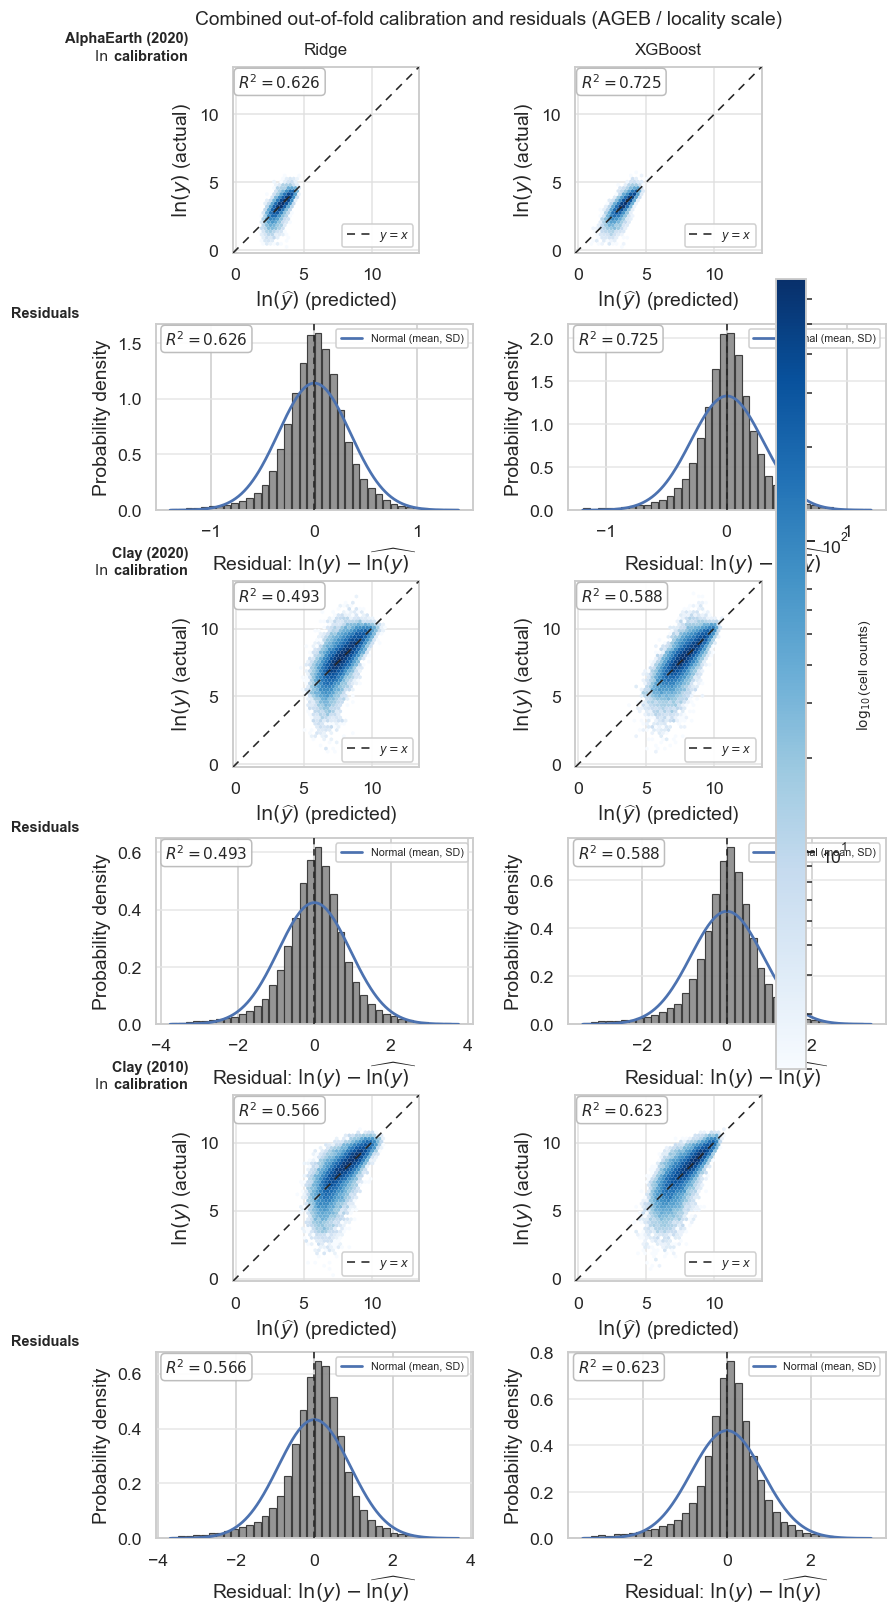

Saved stem ``oof_calibration_residuals_combined`` (.pdf / .png).


In [30]:
# One figure: 6×2 panels — (calibration row, residuals row) × three embedding sources.
# Depends on the calibration cell above: _load_ageb_oof, _subsample, _panel_limits,
# _residual_bin_edges, _norm_pdf, _annotate_r2, _r2_ln, PUBLICATION_SOURCES,
# MAX_POINTS, RNG, _save_report_fig.

_need = [
    "_load_ageb_oof",
    "_subsample",
    "_panel_limits",
    "_residual_bin_edges",
    "_norm_pdf",
    "_annotate_r2",
    "_r2_ln",
    "PUBLICATION_SOURCES",
    "MAX_POINTS",
    "RNG",
    "_save_report_fig",
]
_missing = [n for n in _need if n not in globals()]
if _missing:
    raise RuntimeError(
        "Run the calibration cell above first (missing: " + ", ".join(_missing) + ")."
    )

_bundles: list[tuple[str, str, np.ndarray, np.ndarray, np.ndarray, float, float]] = []
for lab, fold in PUBLICATION_SOURCES:
    d0 = _load_ageb_oof(fold)
    if d0 is None:
        print(f"[combined skip] missing {fold}/analysis_ageb/predictions_oof_emb.parquet")
        continue
    d = _subsample(d0)
    if not all(c in d.columns for c in ["y", "pred_ridge", "pred_xgb"]):
        print(f"[combined skip] {fold}: expected y, pred_ridge, pred_xgb")
        continue
    y = d["y"].to_numpy(dtype=float)
    pr = d["pred_ridge"].to_numpy(dtype=float)
    px = d["pred_xgb"].to_numpy(dtype=float)
    _bundles.append(
        (lab, fold, y, pr, px, _r2_ln(y, pr), _r2_ln(y, px))
    )

if not _bundles:
    print("[combined] No datasets loaded.")
else:
    parts: list[np.ndarray] = []
    for _lab, _fold, yv, prv, pxv, _, __ in _bundles:
        parts.extend([yv, prv, pxv])
    lo = float(np.min(parts))
    hi = float(np.max(parts))
    pad = 0.02 * (hi - lo)
    glo, ghi = lo - pad, hi + pad

    n_src = len(_bundles)
    fig, axes = plt.subplots(2 * n_src, 2, figsize=(8.4, 4.9 * n_src))
    if n_src == 1:
        axes = np.asarray(axes).reshape(2, 2)
    plt.subplots_adjust(left=0.14, right=0.93, top=0.96, bottom=0.05, hspace=0.38, wspace=0.30)

    mappable = None
    cal_axes: list = []
    for i, (lab, fold, yv, prv, pxv, rr2, xr2) in enumerate(_bundles):
        r_cal = 2 * i
        r_res = 2 * i + 1
        for col, (pv, r2v, mname) in enumerate([(prv, rr2, "Ridge"), (pxv, xr2, "XGBoost")]):
            axc = axes[r_cal, col]
            hb = axc.hexbin(
                pv,
                yv,
                gridsize=52,
                mincnt=2,
                extent=(glo, ghi, glo, ghi),
                cmap="Blues",
                linewidths=0.0,
                bins="log",
            )
            mappable = hb
            cal_axes.append(axc)
            axc.plot(
                [glo, ghi],
                [glo, ghi],
                color="0.15",
                ls=(0, (5, 4)),
                lw=1.05,
                zorder=6,
                label=r"$y = x$",
            )
            axc.set_xlim(glo, ghi)
            axc.set_ylim(glo, ghi)
            axc.set_aspect("equal", adjustable="box")
            axc.set_xlabel(r"$\ln(\widehat{y})$ (predicted)")
            axc.set_ylabel(r"$\ln(y)$ (actual)")
            if i == 0:
                axc.set_title(mname, fontsize=11, pad=8)
            axc.grid(True, color="0.88", zorder=0, alpha=0.9)
            axc.legend(loc="lower right", fontsize=7.5, framealpha=0.92)
            _annotate_r2(axc, r2v)

            axr = axes[r_res, col]
            res = yv - pv
            bins = _residual_bin_edges(res)
            axr.hist(
                res,
                bins=bins,
                density=True,
                color="0.55",
                alpha=0.92,
                edgecolor="0.2",
                linewidth=0.75,
                rwidth=0.88,
                zorder=2,
            )
            mu, sig = float(res.mean()), float(res.std(ddof=1))
            if sig > 1e-10:
                xs = np.linspace(bins[0], bins[-1], 300)
                axr.plot(
                    xs,
                    _norm_pdf(xs, mu, sig),
                    color="C0",
                    lw=1.8,
                    zorder=4,
                    label="Normal (mean, SD)",
                )
            axr.axvline(0.0, color="0.15", ls=(0, (4, 3)), lw=1.05, zorder=5)
            axr.set_xlabel(r"Residual: $\ln(y) - \widehat{\ln(y)}$")
            axr.set_ylabel("Probability density")
            axr.legend(loc="upper right", fontsize=7, framealpha=0.92)
            axr.grid(True, axis="y", color="0.9", alpha=0.95, zorder=0)
            _annotate_r2(axr, r2v)

        axes[r_cal, 0].text(
            -0.24,
            1.02,
            lab + "\n" + r"$\ln$ calibration",
            transform=axes[r_cal, 0].transAxes,
            fontsize=9.5,
            fontweight="bold",
            va="bottom",
            ha="right",
        )
        axes[r_res, 0].text(
            -0.24,
            1.02,
            "Residuals",
            transform=axes[r_res, 0].transAxes,
            fontsize=9.5,
            fontweight="bold",
            va="bottom",
            ha="right",
        )

    if mappable is not None:
        cbar = fig.colorbar(mappable, ax=cal_axes, shrink=0.65, pad=0.02, aspect=26)
        cbar.set_label(r"$\log_{10}$(cell counts)", fontsize=9)

    fig.suptitle(
        "Combined out-of-fold calibration and residuals (AGEB / locality scale)",
        fontsize=12.5,
        y=0.995,
    )
    _save_report_fig(fig, "oof_calibration_residuals_combined")
    plt.show()
    print("Saved stem ``oof_calibration_residuals_combined`` (.pdf / .png).")


## Spatial error maps (state choropleth)

Per-state **out-of-fold** metrics from `analysis_ageb/metrics_by_state_emb.csv` (same CV splits as the calibration plots), joined to Mexican **state** polygons from [Natural Earth](https://www.naturalearthdata.com/) (10m admin-1, downloaded on first run via GeoPandas).

**What to look for:** systematic geographic patches — e.g. weaker \(R^2\) or higher MAE on \(\ln\)-density in mining-heavy northern states (Sonora **CVE_ENT 26**, Zacatecas **32**) — that persist across embedding choices vs. noise from small \(n\).

**Requires:** `geopandas` (+ GEOS). **`SPATIAL_MAP_MODEL`:** `"ridge"` or `"xgboost"` (must match the `model` column in the CSV).

**`SHARED_METRIC_LIMITS`:** `False` (default) sets **per-column** color scales and adds a narrow **colorbar on each map**, which keeps geographic contrast visible when one embedding is uniformly better. Set `True` to pool limits across the three columns and use **one colorbar per row** for stricter cross-embedding comparison of absolute levels.

Saved: /Users/henrychen/Desktop/CS-Econ Thesis/deliverables/report/figs/spatial_state_metrics_ridge.pdf | /Users/henrychen/Desktop/CS-Econ Thesis/deliverables/report/figs/spatial_state_metrics_ridge.png


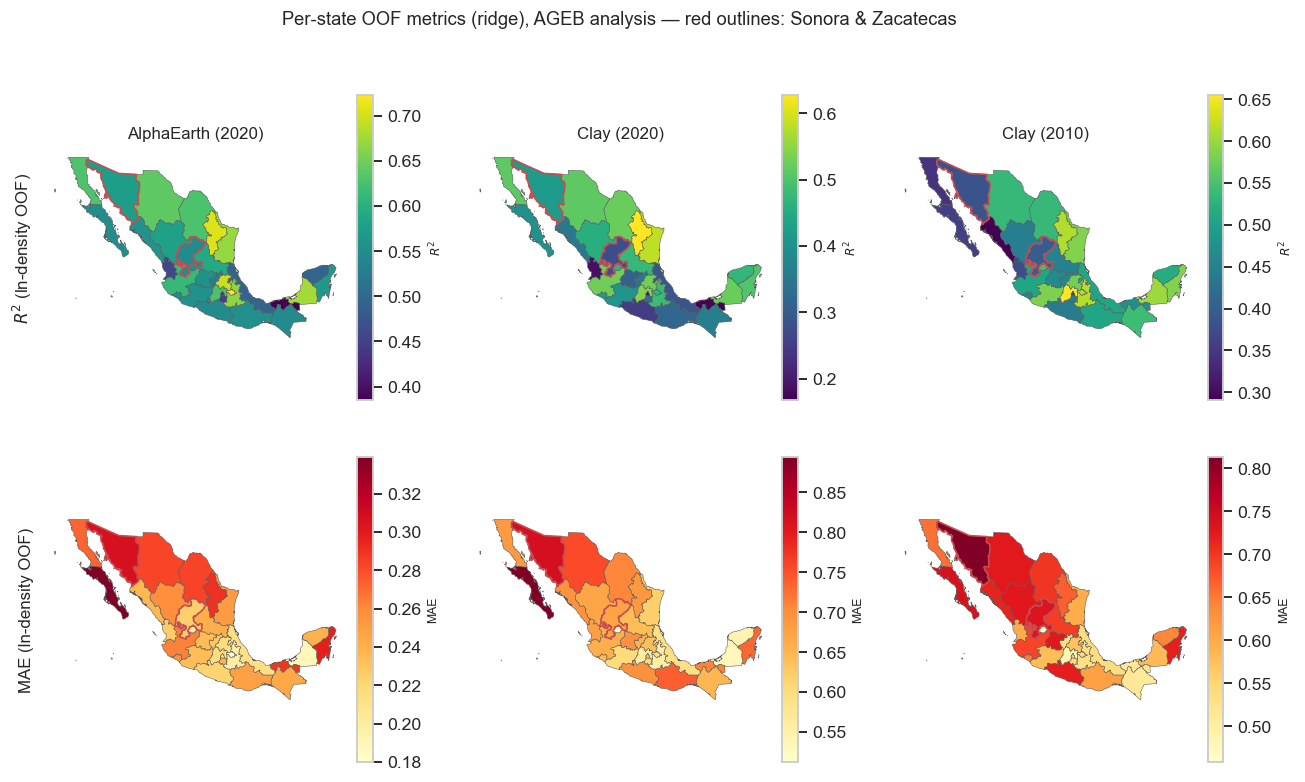

,embedding,CVE_ENT,n,r2,mae
0,alphaearth2020,26,3712,0.572431,0.306160
4,clay2010,26,2416,0.384182,0.813395
2,clay2020,26,3712,0.417807,0.818551
1,alphaearth2020,32,3074,0.547178,0.224513
5,clay2010,32,1514,0.396425,0.733185
3,clay2020,32,3074,0.274936,0.673427


In [17]:
# State choropleths: OOF R² and MAE by embedding source (requires geopandas).
# Uses ``_save_report_fig`` from the calibration cell above — run that cell first if needed.

try:
    import geopandas as gpd
except ImportError as e:
    raise ImportError(
        "Install geopandas for spatial maps (e.g. ``conda install geopandas`` or ``pip install geopandas``)."
    ) from e

from matplotlib import cm
from matplotlib.colors import Normalize

# Match calibration section ordering / labels
_MAP_SOURCES: list[tuple[str, str]] = [
    ("AlphaEarth (2020)", "alphaearth2020"),
    ("Clay (2020)", "clay2020"),
    ("Clay (2010)", "clay2010"),
]

SPATIAL_MAP_MODEL = "ridge"  # or "xgboost"
SHARED_METRIC_LIMITS = False  # True → same vmin/vmax across the three columns per metric row
HIGHLIGHT_CVE = {"26", "32"}  # Sonora, Zacatecas — boundary emphasis only

_NATURAL_EARTH_ADMIN1_URL = (
    "https://naciscdn.org/naturalearth/10m/cultural/ne_10m_admin_1_states_provinces.zip"
)

# ISO 3166-2 (Natural Earth) → INEGI CVE_ENT two-digit string
_ISO2_TO_CVE: dict[str, str] = {
    "MX-AGU": "01",
    "MX-BCN": "02",
    "MX-BCS": "03",
    "MX-CAM": "04",
    "MX-COA": "05",
    "MX-COL": "06",
    "MX-CHP": "07",
    "MX-CHH": "08",
    "MX-DIF": "09",
    "MX-DUR": "10",
    "MX-GUA": "11",
    "MX-GRO": "12",
    "MX-HID": "13",
    "MX-JAL": "14",
    "MX-MEX": "15",
    "MX-MIC": "16",
    "MX-MOR": "17",
    "MX-NAY": "18",
    "MX-NLE": "19",
    "MX-OAX": "20",
    "MX-PUE": "21",
    "MX-QUE": "22",
    "MX-ROO": "23",
    "MX-SLP": "24",
    "MX-SIN": "25",
    "MX-SON": "26",
    "MX-TAB": "27",
    "MX-TAM": "28",
    "MX-TLA": "29",
    "MX-VER": "30",
    "MX-YUC": "31",
    "MX-ZAC": "32",
}


def _load_mx_states_geo() -> gpd.GeoDataFrame:
    admin = gpd.read_file(_NATURAL_EARTH_ADMIN1_URL)
    mx = admin[admin["iso_a2"] == "MX"].copy()
    mx["CVE_ENT"] = mx["iso_3166_2"].map(_ISO2_TO_CVE)
    mx = mx[mx["CVE_ENT"].notna()].copy()
    # Equal-area-ish plot for Mexico (ITRF2008 / Mexico LCC); fall back to lon/lat
    try:
        mx = mx.to_crs(6372)
    except Exception:
        mx = mx.to_crs(4326)
    return mx


def _pick_model_rows(df: pd.DataFrame, model: str) -> pd.DataFrame:
    m = model.strip().lower()
    if m in {"xgb", "xgboost"}:
        return df[df["model"].astype(str).str.lower().isin(["xgboost", "xgb"])].copy()
    if m == "ridge":
        return df[df["model"].astype(str).str.lower() == "ridge"].copy()
    raise ValueError(f"Unknown SPATIAL_MAP_MODEL={model!r}; use 'ridge' or 'xgboost'")


mx_states = _load_mx_states_geo()


def _collect_metrics_tables() -> dict[str, pd.DataFrame]:
    out: dict[str, pd.DataFrame] = {}
    for _lab, fold in _MAP_SOURCES:
        p = RESULTS_DIR / fold / "analysis_ageb" / "metrics_by_state_emb.csv"
        if not p.is_file():
            print(f"[skip maps] missing {p.relative_to(RESULTS_DIR)}")
            continue
        raw = pd.read_csv(p)
        sel = _pick_model_rows(raw, SPATIAL_MAP_MODEL)
        if sel.empty:
            print(f"[skip maps] no rows for model={SPATIAL_MAP_MODEL!r} in {fold}")
            continue
        sel["CVE_ENT"] = sel["state"].astype(str).str.zfill(2)
        out[fold] = sel[["CVE_ENT", "r2", "mae", "n"]]
    return out


_tables = _collect_metrics_tables()
if not _tables:
    print("No per-state metrics loaded; skipping choropleths.")
else:
    # Optional pooled limits
    pooled_r2 = np.concatenate([t["r2"].to_numpy(dtype=float) for t in _tables.values()])
    pooled_mae = np.concatenate([t["mae"].to_numpy(dtype=float) for t in _tables.values()])
    r2_lim = (float(np.nanmin(pooled_r2)), float(np.nanmax(pooled_r2)))
    mae_lim = (float(np.nanmin(pooled_mae)), float(np.nanmax(pooled_mae)))

    fig, axes = plt.subplots(2, 3, figsize=(11.2, 7.6))
    plt.subplots_adjust(
        left=0.03,
        right=0.92 if SHARED_METRIC_LIMITS else 0.99,
        top=0.88,
        bottom=0.06,
        wspace=0.28 if not SHARED_METRIC_LIMITS else 0.06,
        hspace=0.12,
    )

    cmap_r2 = "viridis"
    cmap_mae = "YlOrRd"

    for j, (lab, fold) in enumerate(_MAP_SOURCES):
        ax_r2 = axes[0, j]
        ax_mae = axes[1, j]
        if fold not in _tables:
            ax_r2.axis("off")
            ax_mae.axis("off")
            ax_r2.set_title(lab, fontsize=11)
            continue

        tab = _tables[fold]
        merged = mx_states.merge(tab, on="CVE_ENT", how="left")

        if SHARED_METRIC_LIMITS:
            vr2, vmae = r2_lim, mae_lim
        else:
            vr2 = (float(tab["r2"].min()), float(tab["r2"].max()))
            vmae = (float(tab["mae"].min()), float(tab["mae"].max()))

        merged.plot(
            column="r2",
            ax=ax_r2,
            cmap=cmap_r2,
            vmin=vr2[0],
            vmax=vr2[1],
            legend=False,
            edgecolor="0.35",
            linewidth=0.35,
            missing_kwds={"color": "0.92", "edgecolor": "0.6", "linewidth": 0.25},
        )
        hl = merged[merged["CVE_ENT"].isin(HIGHLIGHT_CVE)]
        if not hl.empty:
            hl.boundary.plot(ax=ax_r2, edgecolor="C3", linewidth=1.05)

        merged.plot(
            column="mae",
            ax=ax_mae,
            cmap=cmap_mae,
            vmin=vmae[0],
            vmax=vmae[1],
            legend=False,
            edgecolor="0.35",
            linewidth=0.35,
            missing_kwds={"color": "0.92", "edgecolor": "0.6", "linewidth": 0.25},
        )
        hl2 = merged[merged["CVE_ENT"].isin(HIGHLIGHT_CVE)]
        if not hl2.empty:
            hl2.boundary.plot(ax=ax_mae, edgecolor="C3", linewidth=1.05)

        ax_r2.set_title(lab, fontsize=11)
        ax_mae.set_title("")
        ax_r2.axis("off")
        ax_mae.axis("off")

        if not SHARED_METRIC_LIMITS:
            sm_cr2 = cm.ScalarMappable(norm=Normalize(vr2[0], vr2[1]), cmap=cmap_r2)
            sm_cr2.set_array([])
            fig.colorbar(sm_cr2, ax=ax_r2, fraction=0.046, pad=0.02).set_label(r"$R^2$", fontsize=8)
            sm_cma = cm.ScalarMappable(norm=Normalize(vmae[0], vmae[1]), cmap=cmap_mae)
            sm_cma.set_array([])
            fig.colorbar(sm_cma, ax=ax_mae, fraction=0.046, pad=0.02).set_label("MAE", fontsize=8)

    axes[0, 0].text(
        -0.02,
        0.5,
        r"$R^2$ (ln-density OOF)",
        transform=axes[0, 0].transAxes,
        rotation=90,
        va="center",
        ha="right",
        fontsize=11,
    )
    axes[1, 0].text(
        -0.02,
        0.5,
        r"MAE (ln-density OOF)",
        transform=axes[1, 0].transAxes,
        rotation=90,
        va="center",
        ha="right",
        fontsize=11,
    )

    mod_slug = SPATIAL_MAP_MODEL.lower().replace(" ", "")
    if SHARED_METRIC_LIMITS:
        sm_r2 = cm.ScalarMappable(norm=Normalize(*r2_lim), cmap=cmap_r2)
        sm_r2.set_array([])
        sm_mae = cm.ScalarMappable(norm=Normalize(*mae_lim), cmap=cmap_mae)
        sm_mae.set_array([])
        fig.colorbar(sm_r2, ax=axes[0, :], fraction=0.035, pad=0.02).set_label(r"$R^2$")
        fig.colorbar(sm_mae, ax=axes[1, :], fraction=0.035, pad=0.02).set_label("MAE")

    fig.suptitle(
        f"Per-state OOF metrics ({SPATIAL_MAP_MODEL}), AGEB analysis — red outlines: Sonora & Zacatecas",
        fontsize=12,
        y=0.97,
    )
    _save_report_fig(fig, f"spatial_state_metrics_{mod_slug}")
    plt.show()

    # Compact benchmark table for highlighted states
    rows = []
    for lab, fold in _MAP_SOURCES:
        if fold not in _tables:
            continue
        t = _tables[fold].set_index("CVE_ENT")
        for ent in sorted(HIGHLIGHT_CVE):
            if ent not in t.index:
                continue
            r = t.loc[ent]
            rows.append(
                {
                    "embedding": fold,
                    "CVE_ENT": ent,
                    "n": int(r["n"]),
                    "r2": float(r["r2"]),
                    "mae": float(r["mae"]),
                }
            )
    if rows:
        bench = pd.DataFrame(rows).sort_values(["CVE_ENT", "embedding"])
        display(bench)


### State-level summary table (AGEB OOF)

**Wide table:** rows are keyed by **state name** only (no abbreviation column). **log pop density** (within-state variance of $y$), **mean area (km²)**, and **median area (km²)** appear **once**, computed from **`STATE_SUMMARY_LABEL_FOLD`** polygons merged to `alphaearth_src/data/embeddings/00_all_mexico_embeddings_combined.csv` for areas. Each embedding run (**Clay 2010**, **Clay 2020**, **AlphaEarth 2020**) contributes **N**, **frac_urban** (AGEB id length 13), and **out-of-fold $R^2$** from `analysis_ageb/metrics_by_state_emb.csv`.

**`STATE_SUMMARY_MODEL`** follows the choropleth cell’s `SPATIAL_MAP_MODEL` when that cell has been run; otherwise Ridge (also accepts XGBoost).

**Exports:** **`deliverables/report/figs/state_summary_ageb_oof_<model>.png`** (raster of the styled table, via ``dataframe_image``), **`state_summary_ageb_oof_<model>.html`**, and flattened **`.csv`**.



In [37]:
# --- State-level characteristics + OOF R²: all three embedding/year runs ---
STATE_SUMMARY_SOURCES: list[tuple[str, str]] = [
    ("Clay (2010)", "clay2010"),
    ("Clay (2020)", "clay2020"),
    ("AlphaEarth (2020)", "alphaearth2020"),
]
# Single source for label dispersion + polygon areas (Var(y), mean/median km²) — not repeated per experiment
STATE_SUMMARY_LABEL_FOLD = "clay2020"
STATE_SUMMARY_MODEL = globals().get("SPATIAL_MAP_MODEL", "ridge")

CVE_ENT_TO_ABBR = {
    f"{k:02d}": v
    for k, v in {
        1: "AGS",
        2: "BC",
        3: "BCS",
        4: "CAM",
        5: "COAH",
        6: "COL",
        7: "CHIS",
        8: "CHIH",
        9: "CDMX",
        10: "DGO",
        11: "GTO",
        12: "GRO",
        13: "HGO",
        14: "JAL",
        15: "MEX",
        16: "MICH",
        17: "MOR",
        18: "NAY",
        19: "NL",
        20: "OAX",
        21: "PUE",
        22: "QRO",
        23: "QROO",
        24: "SLP",
        25: "SIN",
        26: "SON",
        27: "TAB",
        28: "TAMPS",
        29: "TLAX",
        30: "VER",
        31: "YUC",
        32: "ZAC",
    }.items()
}

CVE_ENT_TO_STATE_NAME = {
    "01": "Aguascalientes",
    "02": "Baja California",
    "03": "Baja California Sur",
    "04": "Campeche",
    "05": "Coahuila",
    "06": "Colima",
    "07": "Chiapas",
    "08": "Chihuahua",
    "09": "Ciudad de México",
    "10": "Durango",
    "11": "Guanajuato",
    "12": "Guerrero",
    "13": "Hidalgo",
    "14": "Jalisco",
    "15": "México",
    "16": "Michoacán",
    "17": "Morelos",
    "18": "Nayarit",
    "19": "Nuevo León",
    "20": "Oaxaca",
    "21": "Puebla",
    "22": "Querétaro",
    "23": "Quintana Roo",
    "24": "San Luis Potosí",
    "25": "Sinaloa",
    "26": "Sonora",
    "27": "Tabasco",
    "28": "Tamaulipas",
    "29": "Tlaxcala",
    "30": "Veracruz",
    "31": "Yucatán",
    "32": "Zacatecas",
}

ENT_FROM_ABBR = {v: k for k, v in CVE_ENT_TO_ABBR.items()}
_METRIC_SUBCOLS = ["N", "frac_urban", "R²"]

_EMB_COMBINED = (
    RESULTS_DIR.parent
    / "alphaearth_src"
    / "data"
    / "embeddings"
    / "00_all_mexico_embeddings_combined.csv"
)


def _filter_metrics_model(raw_m: pd.DataFrame, model: str) -> pd.DataFrame:
    mod = str(model).strip().lower()
    if mod in {"xgb", "xgboost"}:
        return raw_m[raw_m["model"].astype(str).str.lower().isin({"xgboost", "xgb"})].copy()
    if mod == "ridge":
        return raw_m[raw_m["model"].astype(str).str.lower() == "ridge"].copy()
    raise ValueError(f"Unknown STATE_SUMMARY_MODEL={model!r}; use 'ridge' or 'xgboost'")


def _label_fold_polygon_frame(label_fold: str) -> pd.DataFrame | None:
    """AGEB rows for STATE_SUMMARY_LABEL_FOLD with state_abbr (for merging label/area stats)."""
    pred_path = RESULTS_DIR / label_fold / "analysis_ageb" / "predictions_oof_emb.parquet"
    if not pred_path.is_file():
        print(f"[label stats] missing {pred_path.relative_to(RESULTS_DIR)}")
        return None
    pred = normalize_pred_frame(pd.read_parquet(pred_path))
    pred["state"] = pred["state"].astype(str).str.zfill(2)
    pred["state_abbr"] = pred["state"].map(CVE_ENT_TO_ABBR)
    return pred[pred["state_abbr"].notna()].copy()


def _log_pop_density_by_state(pred_lf: pd.DataFrame | None) -> pd.Series | None:
    if pred_lf is None or pred_lf.empty:
        return None
    return pred_lf.groupby("state_abbr", sort=False)["y"].var()


def _mean_median_area_km2_by_state(pred_lf: pd.DataFrame | None) -> tuple[pd.Series | None, pd.Series | None]:
    if pred_lf is None or pred_lf.empty:
        return None, None
    if not _EMB_COMBINED.is_file():
        print(f"[note] mean/median area unavailable — missing:\n  {_EMB_COMBINED}")
        idx = pred_lf["state_abbr"].unique()
        na = pd.Series(np.nan, index=pd.Index(idx, name="state_abbr"))
        return na, na.copy()

    area = pd.read_csv(
        _EMB_COMBINED,
        usecols=["CVEGEO", "area_sqkm"],
        dtype={"CVEGEO": str},
    )
    merged = pred_lf.merge(
        area,
        left_on=pred_lf["ageb_id"].astype(str),
        right_on="CVEGEO",
        how="left",
    ).drop(columns=["CVEGEO"], errors="ignore")
    g = merged.groupby("state_abbr", sort=False)
    return g["area_sqkm"].mean(), g["area_sqkm"].median()


def _block_for_fold(fold: str) -> pd.DataFrame | None:
    pred_path = RESULTS_DIR / fold / "analysis_ageb" / "predictions_oof_emb.parquet"
    metrics_path = RESULTS_DIR / fold / "analysis_ageb" / "metrics_by_state_emb.csv"
    if not pred_path.is_file():
        print(f"[skip {fold}] missing {pred_path.relative_to(RESULTS_DIR)}")
        return None
    if not metrics_path.is_file():
        print(f"[skip {fold}] missing {metrics_path.relative_to(RESULTS_DIR)}")
        return None

    pred = normalize_pred_frame(pd.read_parquet(pred_path))
    pred["state"] = pred["state"].astype(str).str.zfill(2)
    pred["state_abbr"] = pred["state"].map(CVE_ENT_TO_ABBR)
    pred = pred[pred["state_abbr"].notna()].copy()
    pred["_urban_len13"] = pred["ageb_id"].astype(str).str.len().eq(13).astype(float)

    grouped = pred.groupby("state_abbr", sort=False)
    chars = pd.DataFrame(
        {
            "N": grouped.size(),
            "frac_urban": grouped["_urban_len13"].mean(),
        }
    )

    raw_m = pd.read_csv(metrics_path)
    sel_m = _filter_metrics_model(raw_m, STATE_SUMMARY_MODEL)
    if sel_m.empty:
        print(f"[skip {fold}] no metrics rows for model={STATE_SUMMARY_MODEL!r}")
        return None
    sel_m = sel_m.copy()
    sel_m["state_abbr"] = sel_m["state"].astype(str).str.zfill(2).map(CVE_ENT_TO_ABBR)
    r2 = sel_m.drop_duplicates("state_abbr").set_index("state_abbr")["r2"].rename("R²")
    chars = chars.join(r2, how="inner")
    return chars


pred_label = _label_fold_polygon_frame(STATE_SUMMARY_LABEL_FOLD)
log_pop_var = _log_pop_density_by_state(pred_label)
mean_area_s, median_area_s = _mean_median_area_km2_by_state(pred_label)

blocks: list[tuple[str, pd.DataFrame]] = []
for lab, fold in STATE_SUMMARY_SOURCES:
    b = _block_for_fold(fold)
    if b is None:
        continue
    missing = [c for c in _METRIC_SUBCOLS if c not in b.columns]
    if missing:
        print(f"[skip {fold}] incomplete columns {missing}")
        continue
    b = b[_METRIC_SUBCOLS]
    b.columns = pd.MultiIndex.from_product([[lab], _METRIC_SUBCOLS])
    blocks.append((lab, b))

if not blocks:
    print("No experiment blocks loaded — check analysis_ageb artifacts.")
else:
    out = pd.concat([df for _, df in blocks], axis=1)
    out.insert(
        0,
        "state_name",
        out.index.map(lambda abbr: CVE_ENT_TO_STATE_NAME.get(ENT_FROM_ABBR.get(abbr, ""), "")),
    )
    if log_pop_var is not None:
        out.insert(1, "log pop density", log_pop_var.reindex(out.index))
    else:
        out.insert(1, "log pop density", np.nan)

    _ma = mean_area_s.reindex(out.index) if mean_area_s is not None else np.nan
    _md = median_area_s.reindex(out.index) if median_area_s is not None else np.nan
    out.insert(2, "mean area (km²)", _ma)
    out.insert(3, "median area (km²)", _md)

    sort_key = ("Clay (2020)", "R²")
    if sort_key not in out.columns:
        r2_tuples = [c for c in out.columns if isinstance(c, tuple) and len(c) > 1 and c[1] == "R²"]
        sort_key = r2_tuples[0] if r2_tuples else None
    if sort_key is not None:
        out = out.sort_values(sort_key, ascending=False)

    out = out.reset_index(drop=True)

    caption = (
        f"{STATE_SUMMARY_MODEL}: single-column descriptors from {STATE_SUMMARY_LABEL_FOLD} polygons "
        "(Var(y), mean/median polygon area via merged AlphaEarth combined embeddings CSV); "
        "per-run N / frac_urban / R² from predictions_oof_emb + metrics_by_state_emb."
    )

    fmt_dict: dict = {
        "log pop density": "{:.3f}",
        "mean area (km²)": "{:.2f}",
        "median area (km²)": "{:.3f}",
    }
    for lab, _fold in STATE_SUMMARY_SOURCES:
        if (lab, "N") not in out.columns:
            continue
        fmt_dict[(lab, "N")] = "{:,}"
        fmt_dict[(lab, "frac_urban")] = "{:.3f}"
        fmt_dict[(lab, "R²")] = "{:.3f}"

    r2_cols = [
        c
        for c in out.columns
        if isinstance(c, tuple) and len(c) > 1 and c[1] == "R²"
    ]
    sty = out.style.format(fmt_dict, na_rep="").hide(axis="index")
    if r2_cols:
        _pool = out[r2_cols].to_numpy(dtype=float).ravel()
        _pool = _pool[np.isfinite(_pool)]
        if _pool.size:
            _lo, _hi = float(_pool.min()), float(_pool.max())
            if _lo == _hi:
                _hi = _lo + 1e-9
            sty = sty.background_gradient(subset=r2_cols, cmap="YlGn", vmin=_lo, vmax=_hi)
    sty = sty.set_caption(caption)

    _REPORT_FIG_DIR = RESULTS_DIR.parent / "deliverables" / "report" / "figs"
    _REPORT_FIG_DIR.mkdir(parents=True, exist_ok=True)
    _model_slug = str(STATE_SUMMARY_MODEL).strip().lower().replace(" ", "_")
    _stem = f"state_summary_ageb_oof_{_model_slug}"
    _html_path = _REPORT_FIG_DIR / f"{_stem}.html"
    _html_path.write_text(sty.to_html(), encoding="utf-8")
    _csv_path = _REPORT_FIG_DIR / f"{_stem}.csv"
    _png_path = _REPORT_FIG_DIR / f"{_stem}.png"
    _flat = out.copy()

    def _csv_header(col):
        if isinstance(col, tuple):
            return " | ".join(str(x) for x in col if str(x) != "")
        return str(col)

    _flat.columns = [_csv_header(c) for c in _flat.columns]
    _flat.to_csv(_csv_path, encoding="utf-8", index=False)

    _saved_paths = [_html_path, _csv_path]
    try:
        import dataframe_image as dfi

        dfi.export(sty, _png_path, dpi=220, table_conversion="matplotlib")
        _saved_paths.append(_png_path)
    except ImportError:
        print(
            "[note] PNG skipped — install dataframe_image "
            "(e.g. ``pip install dataframe_image``)."
        )
    except Exception as _e:
        print(f"[warn] Could not save PNG {_png_path.name}: {_e}")

    print("Saved:", " | ".join(str(p) for p in _saved_paths))

    display(sty)


Saved: /Users/henrychen/Desktop/CS-Econ Thesis/deliverables/report/figs/state_summary_ageb_oof_ridge.html | /Users/henrychen/Desktop/CS-Econ Thesis/deliverables/report/figs/state_summary_ageb_oof_ridge.csv | /Users/henrychen/Desktop/CS-Econ Thesis/deliverables/report/figs/state_summary_ageb_oof_ridge.png


## Temporal cross-analysis (Clay 2010 vs 2020)

All summary metrics below are read from **`clay2020/cross_temporal/`**: three experiments, each with **`metrics_overall_*.json`**, **`predictions_*.parquet`**, and **`metrics_by_state_*.csv`** (written by ``cross_temporal.py``).

| Experiment key | Meaning |
|----------------|---------|
| **`baseline_2010_2020_cv`** | Matched AGEB panel (2010 $\cap$ 2020): **2010 embeddings** $\to$ **2020** $\ln$-density. Random 5-fold **OOF**. |
| **`baseline_delta_2020_cv`** | Same matched panel: **$[$emb$_{2010}$, emb$_{2020}-$emb$_{2010}]$** $\to$ **2020** $\ln$-density. **OOF**. |
| **`transfer_2010_to_2020`** | Train on **all** 2010 labeled AGEBs; predict **2020** $\ln$-density on the **full** 2020 polygon table (**no** OOF on the test year). |

The usual **cross-sectional** benchmark (2020 embeddings $\to$ 2020 labels on the full 2020 sample) lives in `clay2020/analysis_ageb/metrics_overall_emb.json` / Table~8 — not duplicated in this section.

**Change-detection hexbins** restrict all three prediction tables to the **matched** $\approx 52\mathrm{k}$ AGEB intersection so panels are comparable: $\Delta_{\mathrm{act}} = \ln(y_{2020})-\ln(y_{2010})$ (target label $y$ at each census); predicted $\Delta = \widehat{\ln(y_{2020})}-\ln(y_{2010})$. Even when $R^2_\Delta$ is negative, **positive $r$** is informative for decadal tracking.

**Requires:** calibration cell (`_save_report_fig`) and ``normalize_pred_frame`` from earlier.


,Specification,Ridge $R^2$,Ridge MAE,XGB $R^2$,XGB MAE,$n$,Meta
0,"2010 emb $\to$ 2020 (matched AGEBs, 5-fold OOF)",0.5533,0.5741,0.6084,0.5277,"52,086",baseline_2010_2020_cv; emb2010; random 5-fold (seed=0)
1,"$[\mathrm{emb}_{2010},\, \Delta\mathrm{emb}] \to$ 2020 (matched AGEBs, 5-fold OOF)",0.6121,0.5299,0.6389,0.5036,"52,086",baseline_delta_2020_cv; emb2010_plus_delta; random 5-fold (seed=0)
2,Train all 2010 $\to$ predict 2020 (full 2020 grid; no OOF),0.3668,0.7255,0.4555,0.6617,"106,564","transfer_2010_to_2020; train=2010, test=2020"


,Specification,Meta
0,"2010 emb $\to$ 2020 (matched AGEBs, 5-fold OOF)",baseline_2010_2020_cv; emb2010; random 5-fold ...
1,"$[\mathrm{emb}_{2010},\, \Delta\mathrm{emb}] \...",baseline_delta_2020_cv; emb2010_plus_delta; ra...
2,Train all 2010 $\to$ predict 2020 (full 2020 g...,"transfer_2010_to_2020; train=2010, test=2020"



Per-state CSV artifacts (``metrics_by_state_*.csv``):
  metrics_by_state_baseline_2010_2020_cv.csv: 64 rows, columns ['model', 'state', 'r2', 'mae', 'rmse', 'n']...
  metrics_by_state_baseline_delta_2020_cv.csv: 64 rows, columns ['model', 'state', 'r2', 'mae', 'rmse', 'n']...
  metrics_by_state_transfer_2010_to_2020.csv: 64 rows, columns ['model', 'state', 'r2', 'mae', 'rmse', 'n']...
[temporal] matched AGEB panel for $\Delta$ plots: 52,086 rows
Saved: /Users/henrychen/Desktop/CS-Econ Thesis/deliverables/report/figs/temporal_change_hexbin_cross_temporal.pdf | /Users/henrychen/Desktop/CS-Econ Thesis/deliverables/report/figs/temporal_change_hexbin_cross_temporal.png


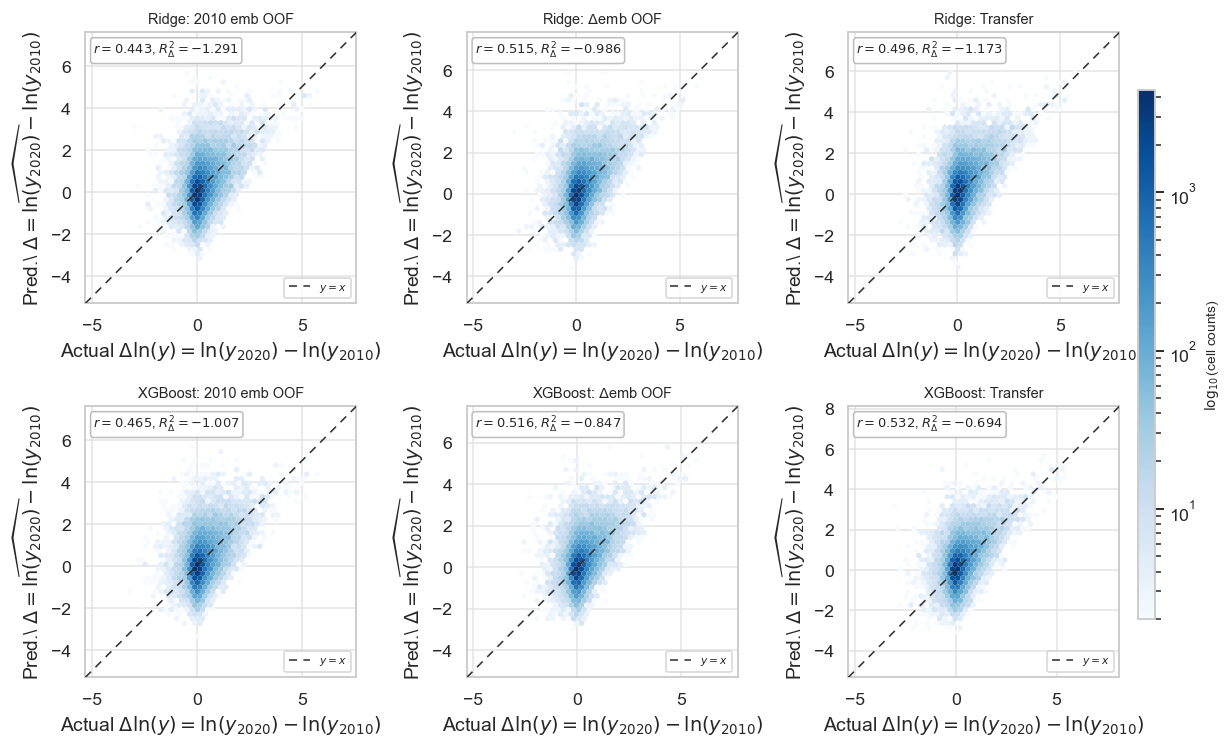

$R^2_\Delta$: sklearn with actual $\Delta$ as truth; can be $<0$ while $r>0$. Saved ``temporal_change_hexbin_cross_temporal`` under /Users/henrychen/Desktop/CS-Econ Thesis/deliverables/report/figs.


In [38]:
# --- clay2020/cross_temporal: three JSON metrics + Δ hexbins (three parquets) ---
# Uses ``normalize_pred_frame`` from above (optional elsewhere) and ``_save_report_fig`` from the calibration cell.

from sklearn.metrics import r2_score

TEMP_CHANGE_MAX_POINTS = 45_000
TEMP_CHANGE_RNG = np.random.default_rng(43)

CROSS_TEMPORAL = RESULTS_DIR / "clay2020" / "cross_temporal"
_path_oof2010 = RESULTS_DIR / "clay2010" / "analysis_ageb" / "predictions_oof_emb.parquet"

CROSS_TEMPORAL_JSON_ROWS: list[tuple[str, str]] = [
    (
        r"2010 emb $\to$ 2020 (matched AGEBs, 5-fold OOF)",
        "metrics_overall_baseline_2010_2020_cv.json",
    ),
    (
        r"$[\mathrm{emb}_{2010},\, \Delta\mathrm{emb}] \to$ 2020 (matched AGEBs, 5-fold OOF)",
        "metrics_overall_baseline_delta_2020_cv.json",
    ),
    (
        r"Train all 2010 $\to$ predict 2020 (full 2020 grid; no OOF)",
        "metrics_overall_transfer_2010_to_2020.json",
    ),
]

PATH_PRED_MATCHED: dict[str, Path] = {
    "baseline": CROSS_TEMPORAL / "predictions_baseline_2010_2020_cv.parquet",
    "delta": CROSS_TEMPORAL / "predictions_baseline_delta_2020_cv.parquet",
    "transfer": CROSS_TEMPORAL / "predictions_transfer_2010_to_2020.parquet",
}


def _json_metrics_row(spec_label: str, path: Path) -> dict | None:
    if not path.is_file():
        print(f"[temporal] missing metrics JSON: {path.relative_to(RESULTS_DIR)}")
        return None
    j = json.loads(path.read_text())
    ridge = j["metrics"]["ridge"]
    xgb = j["metrics"]["xgboost"]
    bits: list[str] = []
    if j.get("experiment"):
        bits.append(str(j["experiment"]))
    if j.get("feature_set"):
        bits.append(str(j["feature_set"]))
    if j.get("cv"):
        bits.append(str(j["cv"]))
    if j.get("train_year") is not None and j.get("test_year") is not None:
        bits.append(f"train={j['train_year']}, test={j['test_year']}")
    return {
        "Specification": spec_label,
        r"Ridge $R^2$": ridge["r2"],
        "Ridge MAE": ridge["mae"],
        r"XGB $R^2$": xgb["r2"],
        "XGB MAE": xgb["mae"],
        "$n$": int(ridge["n"]),
        "Meta": "; ".join(bits),
    }


_rows = []
for lab, fn in CROSS_TEMPORAL_JSON_ROWS:
    row = _json_metrics_row(lab, CROSS_TEMPORAL / fn)
    if row:
        _rows.append(row)

if _rows:
    cross_year_metrics = pd.DataFrame(_rows)
    num_cols = [c for c in cross_year_metrics.columns if c != "Specification"]
    fmt = {c: "{:.4f}" for c in num_cols if c not in ("$n$", "Meta")}
    fmt["$n$"] = "{:,.0f}"
    display(
        cross_year_metrics.style.format(fmt, subset=[c for c in num_cols if c != "Meta"], na_rep="—").set_caption(
            "Clay ``cross_temporal``: rows from ``metrics_overall_*.json``. Meta column documents experiment tags from JSON."
        )
    )
    display(cross_year_metrics[["Specification", "Meta"]])
else:
    cross_year_metrics = pd.DataFrame()
    print("[temporal] No metrics rows assembled (missing cross_temporal JSON artifacts).")

print("\nPer-state CSV artifacts (``metrics_by_state_*.csv``):")
for stem in (
    "baseline_2010_2020_cv",
    "baseline_delta_2020_cv",
    "transfer_2010_to_2020",
):
    p_csv = CROSS_TEMPORAL / f"metrics_by_state_{stem}.csv"
    if p_csv.is_file():
        z = pd.read_csv(p_csv)
        print(f"  {p_csv.name}: {len(z)} rows, columns {list(z.columns)[:6]}...")
    else:
        print(f"  [missing] {p_csv.name}")


def _pred_parquet_xgb_col(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    if "pred_xgboost" in out.columns and "pred_xgb" not in out.columns:
        out["pred_xgb"] = out["pred_xgboost"]
    return out


def _hex_change_panel(ax, x_act: np.ndarray, y_pred: np.ndarray, *, title: str, xlab: str, ylab: str):
    m = np.isfinite(x_act) & np.isfinite(y_pred)
    xa, yp = x_act[m], y_pred[m]
    lo = float(min(xa.min(), yp.min()))
    hi = float(max(xa.max(), yp.max()))
    pad = 0.03 * (hi - lo) if hi > lo else 0.05
    lo, hi = lo - pad, hi + pad
    hb = ax.hexbin(
        xa,
        yp,
        gridsize=52,
        mincnt=2,
        extent=(lo, hi, lo, hi),
        cmap="Blues",
        linewidths=0.0,
        bins="log",
    )
    ax.plot([lo, hi], [lo, hi], color="0.2", ls=(0, (5, 4)), lw=1.05, zorder=6, label=r"$y = x$")
    ax.set_xlim(lo, hi)
    ax.set_ylim(lo, hi)
    ax.set_aspect("equal", adjustable="box")
    ax.set_title(title, fontsize=9.5)
    ax.set_xlabel(xlab)
    ax.set_ylabel(ylab)
    ax.grid(True, color="0.88", zorder=0, alpha=0.85)
    ax.legend(loc="lower right", fontsize=7)
    r_pearson = float(np.corrcoef(xa, yp)[0, 1]) if len(xa) > 1 else float("nan")
    r2_chg = float(r2_score(xa, yp))
    ax.text(
        0.03,
        0.97,
        rf"$r={r_pearson:.3f}$, $R^2_\Delta={r2_chg:.3f}$",
        transform=ax.transAxes,
        fontsize=8.5,
        va="top",
        ha="left",
        bbox=dict(boxstyle="round,pad=0.22", facecolor="white", edgecolor="0.72", alpha=0.92),
        zorder=10,
    )
    return hb


missing_pred = [str(p.relative_to(RESULTS_DIR)) for p in PATH_PRED_MATCHED.values() if not p.is_file()]
if missing_pred:
    print(f"[temporal] Missing prediction parquet(s): {missing_pred}")
elif not _path_oof2010.is_file():
    print("[temporal] Missing clay2010 OOF parquet for $\\ln(y_{2010})$.")
else:
    base = _pred_parquet_xgb_col(pd.read_parquet(PATH_PRED_MATCHED["baseline"]))
    delta = _pred_parquet_xgb_col(pd.read_parquet(PATH_PRED_MATCHED["delta"]))
    xfer = _pred_parquet_xgb_col(pd.read_parquet(PATH_PRED_MATCHED["transfer"]))

    panel = base[["ageb_id", "state", "y"]].rename(columns={"y": "y_ln_2020"})
    panel = panel.merge(
        base[["ageb_id", "pred_ridge", "pred_xgb"]].rename(
            columns={"pred_ridge": "pred_ridge_base", "pred_xgb": "pred_xgb_base"}
        ),
        on="ageb_id",
        how="inner",
    )
    panel = panel.merge(
        delta[["ageb_id", "pred_ridge", "pred_xgb"]].rename(
            columns={"pred_ridge": "pred_ridge_delta", "pred_xgb": "pred_xgb_delta"}
        ),
        on="ageb_id",
        how="inner",
    )
    panel = panel.merge(
        xfer[["ageb_id", "pred_ridge", "pred_xgb"]].rename(
            columns={"pred_ridge": "pred_ridge_xfer", "pred_xgb": "pred_xgb_xfer"}
        ),
        on="ageb_id",
        how="inner",
    )
    y2010 = pd.read_parquet(_path_oof2010, columns=["ageb_id", "y"]).rename(columns={"y": "y_ln_2010"})
    panel = panel.merge(y2010, on="ageb_id", how="inner")
    print(f"[temporal] matched AGEB panel for $\\Delta$ plots: {len(panel):,} rows")

    d_act = panel["y_ln_2020"].to_numpy(dtype=float) - panel["y_ln_2010"].to_numpy(dtype=float)

    heads = [
        ("Ridge", ["pred_ridge_base", "pred_ridge_delta", "pred_ridge_xfer"]),
        ("XGBoost", ["pred_xgb_base", "pred_xgb_delta", "pred_xgb_xfer"]),
    ]
    tags = ["2010 emb OOF", r"$\Delta$emb OOF", "Transfer"]

    fig, axes = plt.subplots(2, 3, figsize=(12.2, 7.15))
    plt.subplots_adjust(left=0.055, right=0.99, top=0.9, bottom=0.08, wspace=0.34, hspace=0.38)
    mappable = None
    idx = np.arange(len(panel))
    if len(idx) > TEMP_CHANGE_MAX_POINTS:
        idx = TEMP_CHANGE_RNG.choice(len(panel), TEMP_CHANGE_MAX_POINTS, replace=False)
    xa = d_act[idx]
    xlab = r"Actual $\Delta\ln(y)=\ln(y_{2020})-\ln(y_{2010})$"
    ylab = r"Pred.\ $\Delta=\widehat{\ln(y_{2020})}-\ln(y_{2010})$"

    y10 = panel["y_ln_2010"].to_numpy(dtype=float)
    for i, (hname, pred_cols) in enumerate(heads):
        for j, pc in enumerate(pred_cols):
            dp = panel[pc].to_numpy(dtype=float) - y10
            yp = dp[idx]
            hb = _hex_change_panel(
                axes[i, j],
                xa,
                yp,
                title=f"{hname}: {tags[j]}",
                xlab=xlab,
                ylab=ylab,
            )
            mappable = hb

    cbar = fig.colorbar(mappable, ax=axes.ravel().tolist(), shrink=0.82, pad=0.015, aspect=32)
    cbar.set_label(r"$\log_{10}$(cell counts)", fontsize=9)
    # fig.suptitle(
    #     r"Clay matched AGEBs: $\Delta\ln(y)$ actual vs.\ predicted — three ``cross_temporal`` parquets",
    #     fontsize=11.5,
    #     y=0.98,
    # )
    _save_report_fig(fig, "temporal_change_hexbin_cross_temporal")
    plt.show()

    print(
        "$R^2_\\Delta$: sklearn with actual $\\Delta$ as truth; can be $<0$ while $r>0$. "
        f"Saved ``temporal_change_hexbin_cross_temporal`` under {CAL_RES_FIG_DIR.resolve()}."
    )


## Table 8 — Out-of-fold $R^2$ by embedding source and spatial scale

Summary table aligned with the thesis: **rows** = embedding source × (Ridge / XGBoost); **columns** = polygon (AGEB / locality) vs municipio rollup, each with $R^2$ on the log-density target and $R^2$ on the **naive** back-transformed density scale ($\exp(\cdot)$ on $y$ and on predictions — no smearing / bias correction).

Uses `predictions_oof_emb.parquet` from each experiment’s `analysis_ageb/` and `analysis_muni_rollup/` (CLAY analysis runs; AlphaEarth via `export_results_analysis_artifacts.py`).

In [7]:
import numpy as np
from sklearn.metrics import r2_score

# Row order matches thesis table
TABLE8_SOURCES: list[tuple[str, str]] = [
    ("AlphaEarth (2020 labels)", "alphaearth2020"),
    ("Clay (2020 labels)", "clay2020"),
    ("Clay (2010 labels)", "clay2010"),
]

COLS_TABLE8 = pd.MultiIndex.from_tuples(
    [
        ("Polygon level (AGEB and localities)", r"$R^2_{\ln}$"),
        ("Polygon level (AGEB and localities)", r"$R^2_{\mathrm{orig}}$"),
        ("Municipality level", r"$R^2_{\ln}$"),
        ("Municipality level", r"$R^2_{\mathrm{orig}}$"),
    ],
    names=["Spatial scale", "Metric"],
)


def _norm_pred_cols(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    if "pred_xgboost" in out.columns and "pred_xgb" not in out.columns:
        out["pred_xgb"] = out["pred_xgboost"]
    return out


def _r2_ln(y: np.ndarray, p: np.ndarray) -> float:
    return float(r2_score(y, p))


def _r2_orig(y_log: np.ndarray, p_log: np.ndarray) -> float:
    """Naive density-scale R²: exp(log density), no smearing / bias correction."""
    return float(r2_score(np.exp(y_log), np.exp(p_log)))


def _load_oof_table8(folder: str, analysis: str) -> pd.DataFrame | None:
    p = RESULTS_DIR / folder / analysis / "predictions_oof_emb.parquet"
    if not p.is_file():
        return None
    return _norm_pred_cols(pd.read_parquet(p))


def build_table8() -> pd.DataFrame:
    rows_idx: list[tuple[str, str]] = []
    rows_data: list[list[float]] = []

    for emb_label, folder in TABLE8_SOURCES:
        poly = _load_oof_table8(folder, "analysis_ageb")
        muni = _load_oof_table8(folder, "analysis_muni_rollup")
        for head, pred_col in [("Ridge", "pred_ridge"), ("XGBoost", "pred_xgb")]:
            rows_idx.append((emb_label, head))
            chunk: list[float] = []
            for d in (poly, muni):
                if d is None or pred_col not in d.columns:
                    chunk.extend([np.nan, np.nan])
                else:
                    y = d["y"].to_numpy(dtype=float)
                    pr = d[pred_col].to_numpy(dtype=float)
                    chunk.append(_r2_ln(y, pr))
                    chunk.append(_r2_orig(y, pr))
            rows_data.append(chunk)

    idx = pd.MultiIndex.from_tuples(rows_idx, names=["Embedding setup", "Head"])
    return pd.DataFrame(rows_data, index=idx, columns=COLS_TABLE8)


table8 = build_table8()
display(
    table8.style.format("{:.3f}", na_rep="—").set_caption(
        "Table 8 (placeholder caption). Out-of-fold regression metrics by embedding source and census year."
    )
)

print(
    "\nNotes: (1) $R^2_{\\ln}$ is sklearn $R^2$ on the log-density target. "
    "(2) $R^2_{\\mathrm{orig}}$ uses the same naive back-transform $\\exp(\\cdot)$ on "
    "$y$ and on predictions (document if you later add bias correction / smearing). "
    "(3) RMSE / MAE rows can be added in the same pattern when results are final."
)


Notes: (1) $R^2_{\ln}$ is sklearn $R^2$ on the log-density target. (2) $R^2_{\mathrm{orig}}$ uses the same naive back-transform $\exp(\cdot)$ on $y$ and on predictions (document if you later add bias correction / smearing). (3) RMSE / MAE rows can be added in the same pattern when results are final.


In [9]:
# Prefer OOF prediction parquets for each experiment / analysis
# Set to an int to cap figures (useful for CI / large trees); None = plot all.
PLOT_LIMIT: int | None = None


def _sort_pred_paths(paths: list[Path]) -> list[Path]:
    """Order: known experiments first, then analysis_ageb / muni subdirs, then path."""

    def sort_key(p: Path) -> tuple:
        rel = p.relative_to(RESULTS_DIR)
        parts = rel.parts
        exp = parts[0] if parts else ""
        ana = parts[1] if len(parts) > 1 else ""
        er = EXPERIMENT_ORDER.index(exp) if exp in EXPERIMENT_ORDER else 999
        ar = ANALYSIS_ORDER.index(ana) if ana in ANALYSIS_ORDER else 999
        return (er, ar, str(rel))

    return sorted(paths, key=sort_key)


_oof_raw = [p for p in parquet_paths if p.name.startswith("predictions_oof")]
_oof_set = set(_oof_raw)
oof_paths = _sort_pred_paths(_oof_raw)
other_pred = _sort_pred_paths([p for p in parquet_paths if p not in _oof_set])


def _plot_list(paths: list[Path], heading: str) -> None:
    print(heading)
    for i, p in enumerate(paths):
        if PLOT_LIMIT is not None and i >= PLOT_LIMIT:
            print(f"  ... stopped at PLOT_LIMIT={PLOT_LIMIT}")
            break
        rel = p.relative_to(RESULTS_DIR)
        df = pd.read_parquet(p)
        plot_pred_diagnostics(df, title=str(rel))
        plt.close("all")


_plot_list(oof_paths, "\n--- OOF prediction parquets ---")
_plot_list(other_pred, "\n--- Other prediction tables (cross-temporal, etc.) ---")


--- OOF prediction parquets ---


NameError: name 'plot_pred_diagnostics' is not defined

## Optional: load every parquet into a dict

Use this for custom tables — **warning:** large files will use a lot of memory.

In [ ]:
def load_all_parquets(base: Path, *, max_rows_preview: int = 3) -> dict[str, pd.DataFrame]:
    out: dict[str, pd.DataFrame] = {}
    for p in sorted(base.rglob("*.parquet")):
        key = str(p.relative_to(base))
        out[key] = pd.read_parquet(p)
    print(f"Loaded {len(out)} parquet tables")
    for k, v in out.items():
        print(f"  {k}: shape {v.shape}, columns {list(v.columns)[:12]}{'...' if v.shape[1] > 12 else ''}")
        display(v.head(max_rows_preview))
    return out


# Uncomment to load everything at once:
# all_tables = load_all_parquets(RESULTS_DIR)